In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, kruskal

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14,6)

In [29]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [30]:
df = pd.concat([
    ethiopia,
    kenya,
    nigeria,
    sudan,
    tanzania
], ignore_index=True)

In [31]:
df["DATE"] = pd.to_datetime(df["DATE"])
df["YEAR"] = df["DATE"].dt.year
df["MONTH"] = df["DATE"].dt.month

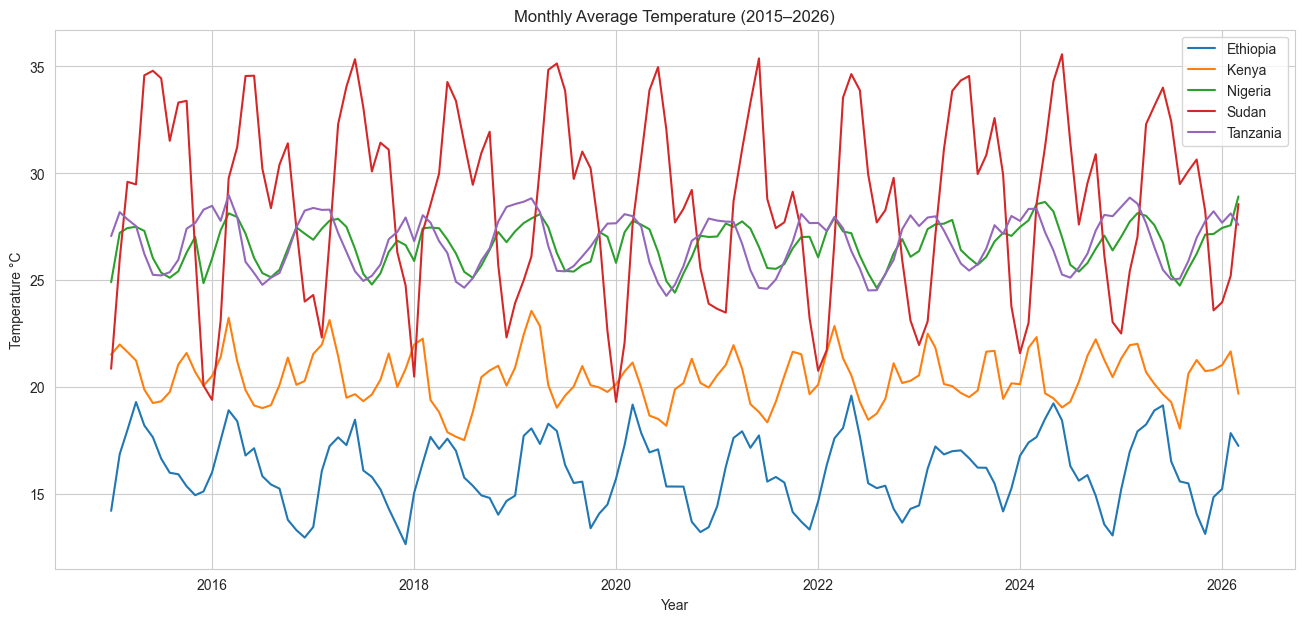

In [32]:
temp = df[(df["YEAR"] >= 2015) & (df["YEAR"] <= 2026)]

monthly_temp = temp.groupby(
    ["Country","YEAR","MONTH"]
)["T2M"].mean().reset_index()

monthly_temp["YM"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" +
    monthly_temp["MONTH"].astype(str)
)

plt.figure(figsize=(16,7))

for c in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == c]
    plt.plot(subset["YM"], subset["T2M"], label=c)

plt.title("Monthly Average Temperature (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Temperature °C")
plt.legend()
plt.show()

In [33]:
temp_summary = df.groupby("Country")["T2M"].agg(
    Mean="mean",
    Median="median",
    Std="std"
).round(2)

temp_summary

,Mean,Median,Std
Country,,,
Ethiopia,16.07,16.04,1.90
Kenya,20.43,20.36,1.44
Nigeria,26.66,26.82,1.12
Sudan,28.76,29.16,4.68
Tanzania,26.80,26.99,1.33


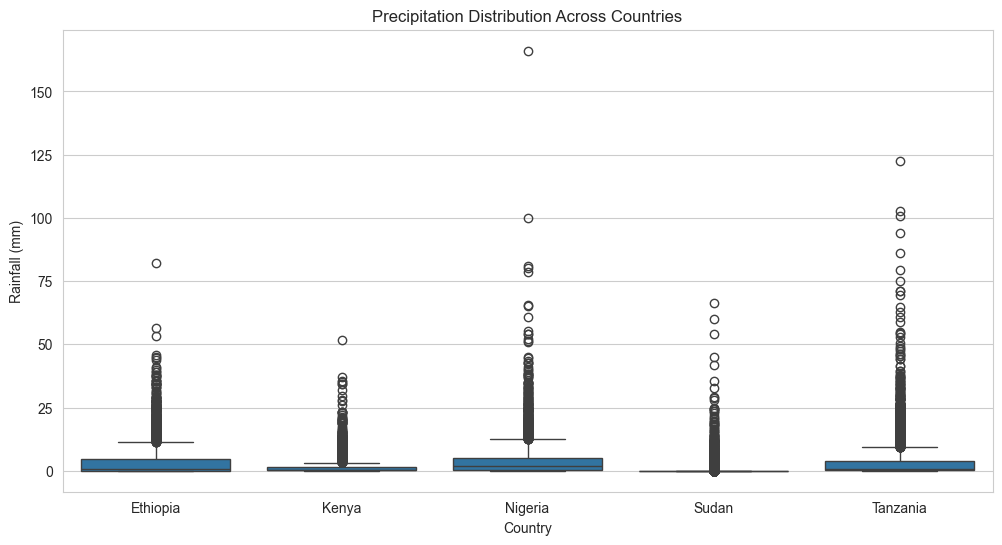

In [34]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Country",
    y="PRECTOTCORR"
)

plt.title("Precipitation Distribution Across Countries")
plt.ylabel("Rainfall (mm)")
plt.show()

In [35]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(
    Mean="mean",
    Median="median",
    Std="std"
).round(2)

rain_summary

,Mean,Median,Std
Country,,,
Ethiopia,3.63,0.82,6.29
Kenya,1.47,0.38,3.18
Nigeria,4.21,1.84,7.27
Sudan,0.64,0.00,3.06
Tanzania,3.74,0.64,8.00


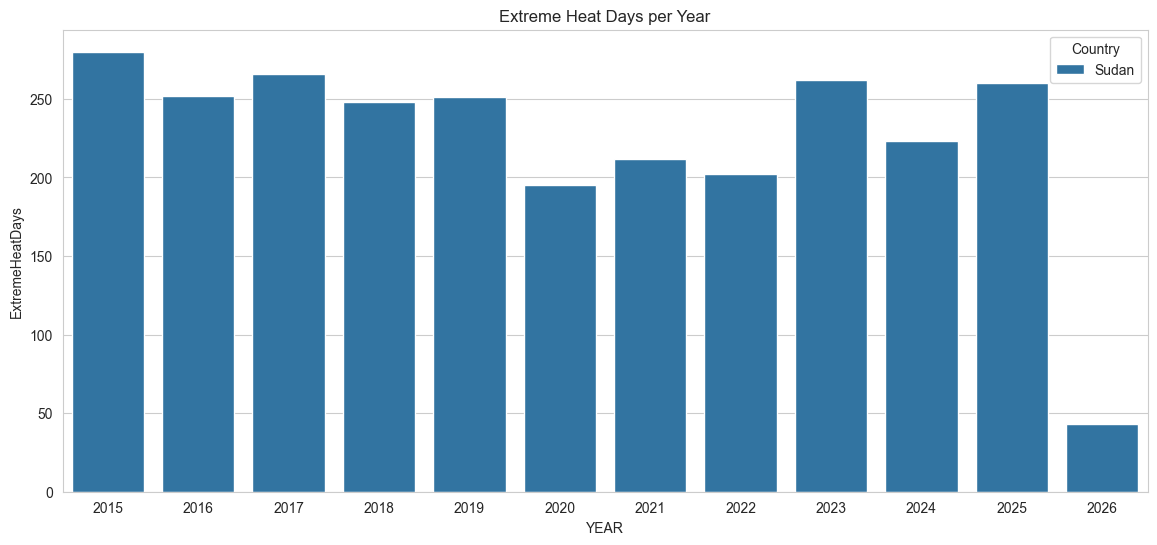

In [36]:
heat = df[df["T2M_MAX"] > 35]

heat_counts = heat.groupby(
    ["Country","YEAR"]
).size().reset_index(name="ExtremeHeatDays")

plt.figure(figsize=(14,6))
sns.barplot(data=heat_counts, x="YEAR", y="ExtremeHeatDays", hue="Country")
plt.title("Extreme Heat Days per Year")
plt.show()

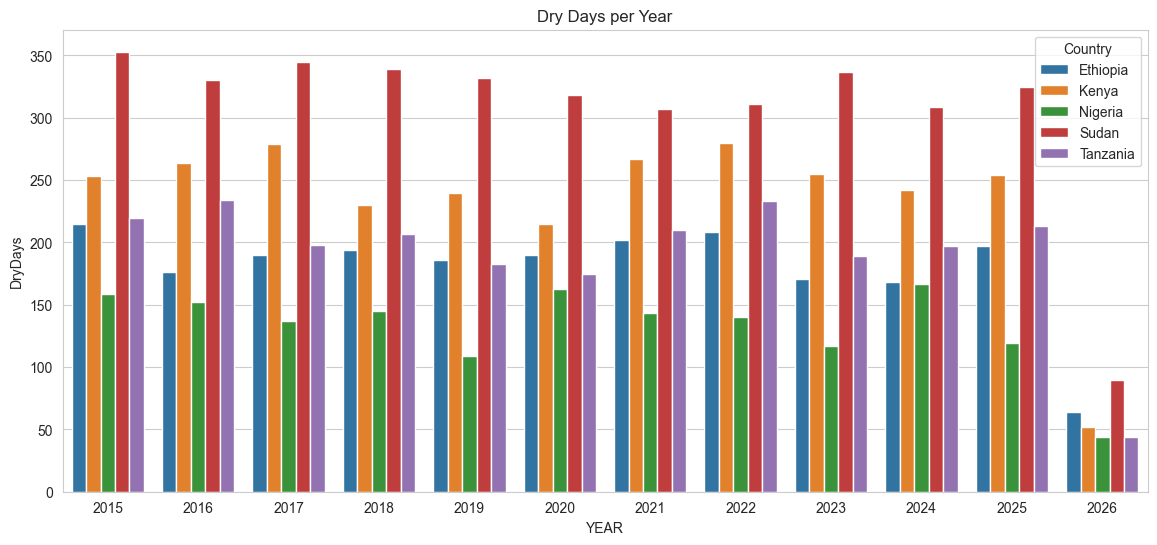

In [37]:
dry = df[df["PRECTOTCORR"] < 1].copy()
dry["Dry"] = 1

dry_counts = dry.groupby(
    ["Country","YEAR"]
).size().reset_index(name="DryDays")


plt.figure(figsize=(14,6))
sns.barplot(data=dry_counts, x="YEAR", y="DryDays", hue="Country")
plt.title("Dry Days per Year")
plt.show()


In [38]:
print(df["T2M"].dtype)

for c in df["Country"].unique():
    vals = df[df["Country"] == c]["T2M"].dropna()
    print(c, len(vals))

float64
Ethiopia 4108
Kenya 4108
Nigeria 4108
Sudan 4108
Tanzania 4108


In [39]:
df["T2M"] = pd.to_numeric(df["T2M"], errors="coerce")

In [40]:
for c in df["Country"].unique():
    vals = df[df["Country"] == c]["T2M"].dropna()
    print(c, len(vals))

Ethiopia 4108
Kenya 4108
Nigeria 4108
Sudan 4108
Tanzania 4108


In [43]:
from scipy.stats import f_oneway

groups = []

for c in df["Country"].unique():
    vals = df[df["Country"] == c]["T2M"].dropna()
    if len(vals) >= 2:
        groups.append(vals)

stat, p = f_oneway(*groups)

print("P-value:", p)

P-value: 0.0


## Statistical Test Interpretation

A one-way ANOVA test was conducted to compare average temperatures (T2M) across the five countries.

The resulting p-value was less than 0.05 (reported as 0.0), indicating statistically significant differences in mean temperatures among the countries.

This suggests that observed temperature variations are unlikely to be due to random chance and reflect real climatic differences across the region.

In [45]:
ranking = pd.DataFrame({
    "AvgTemp": temp_mean,
    "RainVariability": rain_std,
    "ExtremeHeatDays": heat_days,
    "DryDays": dry_days
}).fillna(0)

# Min-Max Normalization
for col in ranking.columns:
    ranking[col + "_Norm"] = (
        ranking[col] - ranking[col].min()
    ) / (
        ranking[col].max() - ranking[col].min()
    )

# Weighted Climate Vulnerability Score
ranking["ClimateScore"] = (
    ranking["AvgTemp_Norm"] * 0.25 +
    ranking["RainVariability_Norm"] * 0.25 +
    ranking["ExtremeHeatDays_Norm"] * 0.25 +
    ranking["DryDays_Norm"] * 0.25
)

ranking = ranking.sort_values("ClimateScore", ascending=False)

ranking

,AvgTemp,RainVariability,ExtremeHeatDays,DryDays,AvgTemp_Norm,RainVariability_Norm,ExtremeHeatDays_Norm,DryDays_Norm,ClimateScore
Country,,,,,,,,,
Sudan,28.759007,3.057672,2694.0,3696,1.000000,0.000000,1.0,1.000000,0.750000
Tanzania,26.802422,8.003947,0.0,2303,0.845823,1.000000,0.0,0.336982,0.545701
Nigeria,26.656928,7.266742,0.0,1595,0.834358,0.850958,0.0,0.000000,0.421329
Kenya,20.427600,3.180228,0.0,2831,0.343493,0.024777,0.0,0.588291,0.239140
Ethiopia,16.068500,6.289061,0.0,2161,0.000000,0.653297,0.0,0.269396,0.230673


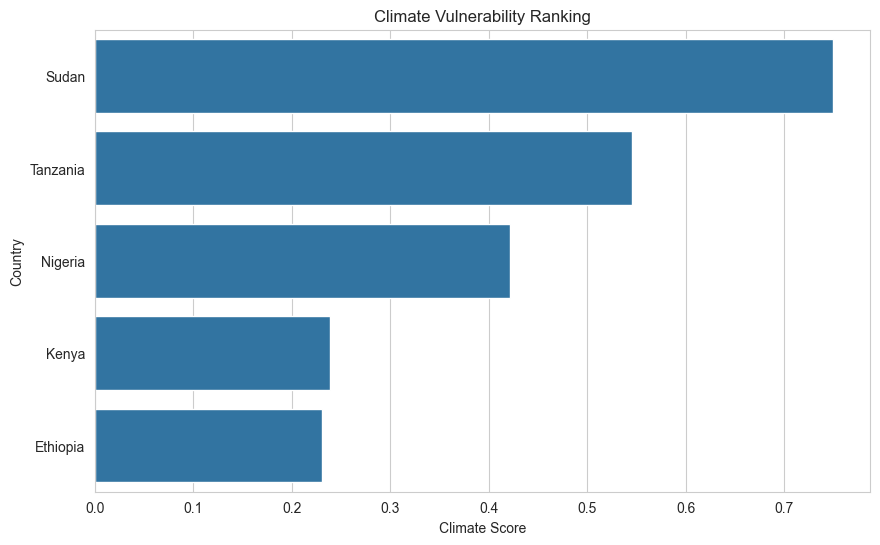

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=ranking["ClimateScore"],
    y=ranking.index
)

plt.title("Climate Vulnerability Ranking")
plt.xlabel("Climate Score")
plt.ylabel("Country")
plt.show()

## Climate Vulnerability Ranking

A composite **Climate Vulnerability Index** was created using four indicators:

- Average temperature  
- Rainfall variability  
- Extreme heat frequency (days above 35°C)  
- Dry-day frequency (days with rainfall below 1 mm)  

Each metric was normalized using Min-Max scaling (0–1 range) so that no single variable dominated the final score.

### Overall Results

The analysis identifies **Sudan as the most climate-vulnerable country** among the five countries studied. This ranking is driven by:

- The highest average temperature  
- The highest number of dry days  
- The only country with substantial extreme heat events above 35°C  

These results indicate severe combined heat and drought stress.

**Tanzania ranks second**, mainly due to high rainfall variability and warm temperatures, suggesting increased flood and drought risk.

**Nigeria ranks third**, reflecting warm conditions and moderate rainfall instability.

**Kenya and Ethiopia rank lower overall**, but both remain climate-sensitive. Kenya shows high dry-day frequency, while Ethiopia faces risks linked to rainfall irregularity and dependence on rain-fed agriculture.

### Key Interpretation

The findings show that climate vulnerability is multidimensional. Some countries face stronger heat stress, while others are more exposed to rainfall instability or drought. This highlights the need for **country-specific adaptation strategies** across the region.

## COP32 Policy Findings

1. Sudan is the most climate-stressed country in the comparison, with severe heat exposure and persistent dryness.

2. Tanzania demonstrates the most unstable rainfall behavior, increasing risks of floods, crop disruption, and water insecurity.

3. Nigeria faces warming pressure and moderate rainfall variability, suggesting rising long-term vulnerability.

4. Ethiopia has comparatively lower temperatures, but rainfall irregularity and dry conditions still pose serious agricultural risks.

5. Ethiopia should champion targeted climate finance for Sudan and East African resilience programs, supported by clear cross-country evidence of heat and drought stress.